##### The goal of this exercise is to get into some first contact with Python, Pandas data frames, and the many opportunities how to quickly generate static charts from data frames.

For the first exercise, load the provided CSV file, do some data cleaning, and check if your cleaning operation was successful using visualization. For inspiration, browse through some Kaggle notebooks. The original data was downloaded from Kaggle. 

The main purpose of the notebook is to preprocess the CSV file for further visualization. The following steps have to be performed: 


- Read the CSV using Pandas. The data has been slightly preprocessed in Excel to clean and simplify it. See the pandas.read_csv documentation to check how to parse the CSV correctly! (0.5 points)
- Remove unusable rows. The provided CSV may contain rows containing aggregated values or headers we do not need for our final visualization (we are only interested in the individual indicators, not their grouping into pre-defined categories). These rows need to be removed. (0.75 points)
- Take care of missing values. Sci-kit learn provides different data imputation methods. (0.75 points)
    (Hint: You may need to impute before you completely filter your data-frame. You need to make an educated judgment). 
- Visualize the data (twice). Every submitted notebook should contain at least two visualizations using at least two different Python visualization libraries. A list of the most wide-spread Python visualization libraries can be found in this article. You must concisely describe and explain each visualization and your decisions in a Markdown field. You will not receive the points for this task if you did not add a description/explanation. (max. 1.25 points per visualization) Only the first two visualizations will be graded. Submitting more than two visualizations will not result in additional points.
- Save the resulting table as CSV. To be sure that the data is correctly saved, you can load it again. You will have to work with this clean dataset for the second exercise. (0.5 points)


# Exercise 1: Data Preprocessing and Visualization

##### The goal of this exercise is to get into some first contact with Python, Pandas data frames, and the many opportunities how to quickly generate static charts from data frames.

### Step 1: Read the CSV using Pandas

In [28]:
import pandas as pd
import numpy as np

# Load the provided CSV file
data = pd.read_csv('agriRuralDevelopment.csv')

print(f"Original Data Shape: {data.shape}")
data.head(3)

Original Data Shape: (13908, 55)


,Country Name,Country Code,year,Access to electricity (% of population),"Access to electricity, rural (% of rural population)",Agricultural irrigated land (% of total agricultural land),Agricultural land (% of land area),Agricultural land (sq. km),"Agricultural machinery, tractors","Agricultural machinery, tractors per 100 sq. km of arable land",...,Permanent cropland (% of land area),"Population, total",Rural land area (sq. km),Rural land area where elevation is below 5 meters (% of total land area),Rural land area where elevation is below 5 meters (sq. km),Rural population,Rural population (% of total population),Rural population growth (annual %),Rural population living in areas where elevation is below 5 meters (% of total population),Surface area (sq. km)
0,Afghanistan,AFG,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,8996973.0,NaN,NaN,NaN,8241137.0,91.599,NaN,NaN,NaN
1,Afghanistan,AFG,1961,NaN,NaN,NaN,57.745918,377000.0,120.0,0.156863,...,0.076586,9169410.0,NaN,NaN,NaN,8373138.0,91.316,1.589040,NaN,652860.0
2,Afghanistan,AFG,1962,NaN,NaN,NaN,57.837821,377600.0,150.0,0.194805,...,0.091903,9351441.0,NaN,NaN,NaN,8512056.0,91.024,1.645479,NaN,652860.0


### Step 2 &amp; 3: Remove Unusable Rows and Take Care of Missing Values
We first drop columns that are overwhelmingly empty (>60% missing data) to avoid introducing massive noise. We then impute the remaining dataset using `KNNImputer`. 

*Note: As per the hints, we impute BEFORE filtering out the aggregated regional rows (like 'World' or 'European Union'). Doing it in this order allows the imputer to use the regional averages to better estimate the missing values of individual countries.*

In [29]:
from sklearn.impute import KNNImputer

# 1. Educated Judgment: Drop columns missing more than 60% of their data
threshold = 0.6
missing_ratio = data.isna().sum() / len(data)
cols_to_drop = missing_ratio[missing_ratio > threshold].index
data_reduced = data.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns due to excessive missing values.")

# 2. Impute BEFORE filtering rows
df_numerical = data_reduced.set_index(['Country Name', 'Country Code', 'year'])

print("Imputing missing values on the full dataset... (this may take a few seconds)")
imputer = KNNImputer(n_neighbors=5)
imputed_data = imputer.fit_transform(df_numerical)

df_imputed = pd.DataFrame(imputed_data, columns=df_numerical.columns, index=df_numerical.index).reset_index()

# 3. Filter out the unusable regional aggregated rows
regions_to_remove = [
    'Arab World', 'Caribbean small states', 'Central Europe and the Baltics',
    'East Asia & Pacific', 'Europe & Central Asia', 'European Union',
    'Latin America & Caribbean', 'Middle East & North Africa', 'North America',
    'Small states', 'South Asia', 'Sub-Saharan Africa', 'World'
]

df_clean = df_imputed[~df_imputed['Country Name'].isin(regions_to_remove)].copy()

print(f"Final cleaned shape: {df_clean.shape}")
print(f"Missing values remaining: {df_clean.isna().sum().sum()}")

Dropped 14 columns due to excessive missing values.
Imputing missing values on the full dataset... (this may take a few seconds)
Final cleaned shape: (13115, 41)
Missing values remaining: 0


### Step 4: Visualize the Data (Twice)

Below are two distinct visualizations created using different plotting libraries (`Seaborn` and `Pandas/Matplotlib`) to investigate the trends in the cleaned dataset.

#### Visualization 1: Rural Population Trend (Seaborn &amp; Matplotlib)

**Description &amp; Decision:** 
We used a line chart from the `seaborn` and `matplotlib` libraries to visualize the change in "Rural population (% of total population)" over time from 1960 to 2020. I selected four diverse, large countries (Brazil, China, India, and the United States) to keep the chart readable. A line chart is the most effective way to display continuous time-series data. The visualization clearly shows a historic, ongoing global trend of urbanization, with the rural population percentage declining smoothly across all these distinct economies.

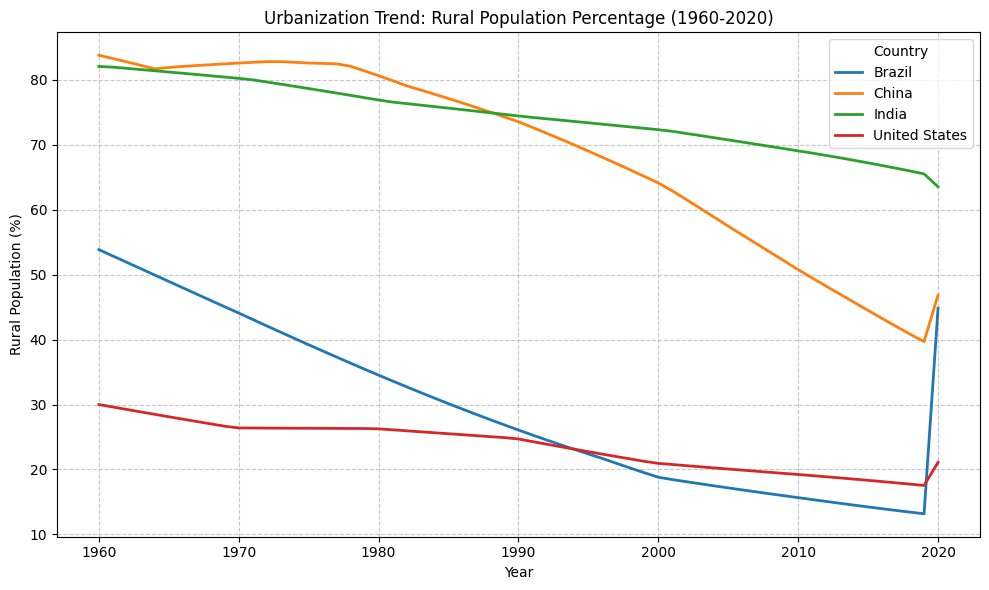

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select a few major countries to keep the plot readable
target_countries = ['Brazil', 'China', 'India', 'United States']
df_trend = df_clean[df_clean['Country Name'].isin(target_countries)]

# Create the plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_trend, x='year', y='Rural population (% of total population)', hue='Country Name', linewidth=2)

plt.title('Urbanization Trend: Rural Population Percentage (1960-2020)')
plt.xlabel('Year')
plt.ylabel('Rural Population (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Country')
plt.tight_layout()
plt.show()

#### Visualization 2: GDP vs. Agriculture Reliance (Pandas Native Plot)

**Description &amp; Decision:**
For the second visualization, we used a Pandas native scatter plot (backed by matplotlib) for the year 2020. It plots "GDP per capita (current US$)" against "Agriculture, forestry, and fishing, value added (% of GDP)". A scatter plot is the standard choice for visualizing the correlation between two continuous variables. By visualizing this, we can observe a clear inverse relationship: countries with higher GDP per capita tend to have a much smaller percentage of their GDP coming from agriculture, highlighting the shift towards service and industrial sectors in wealthier nations. 

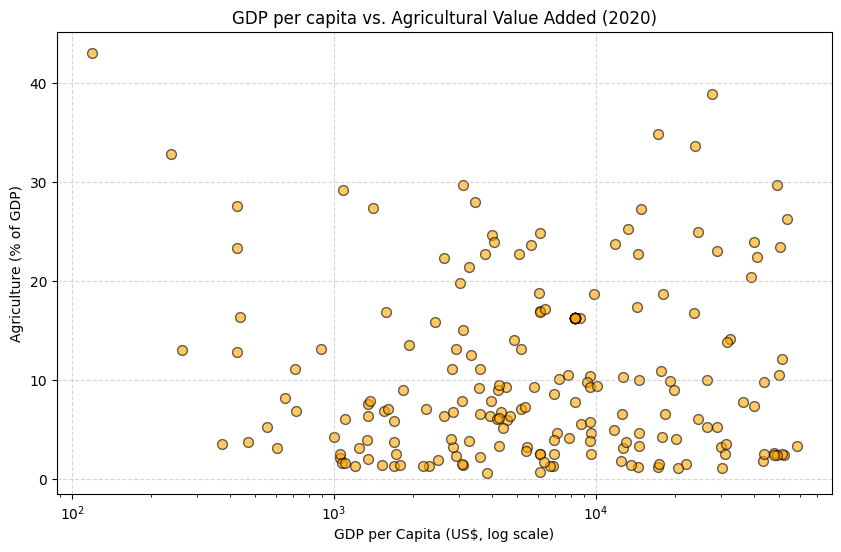

In [31]:
# Filter data for a recent year to compare across countries
df_2020 = df_clean[df_clean['year'] == 2020]

ax = df_2020.plot(
    kind='scatter',
    x='GDP per capita (current US$)', 
    y='Agriculture, forestry, and fishing, value added (% of GDP)',
    figsize=(10, 6),
    alpha=0.6,
    color='orange',
    edgecolor='k',
    s=50,
    title='GDP per capita vs. Agricultural Value Added (2020)'
)

# Use a log scale for GDP as it is highly skewed
ax.set_xscale('log')
ax.set_xlabel('GDP per Capita (US$, log scale)')
ax.set_ylabel('Agriculture (% of GDP)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Step 5: Save the Resulting Table as CSV

In [32]:
# Save the resulting table as CSV
cleaned_filename = 'agriRuralDevelopment_cleaned.csv'
df_clean.to_csv(cleaned_filename, index=False)
print(f"Data saved successfully to {cleaned_filename}")

# Load it again to be sure that the data is correctly saved
df_loaded = pd.read_csv(cleaned_filename)
print("\nData loaded successfully for verification.")
print(f"Loaded data shape: {df_loaded.shape}")
df_loaded.head(3)

Data saved successfully to agriRuralDevelopment_cleaned.csv

Data loaded successfully for verification.
Loaded data shape: (13115, 41)


,Country Name,Country Code,year,Agricultural land (% of land area),Agricultural land (sq. km),"Agricultural machinery, tractors","Agricultural machinery, tractors per 100 sq. km of arable land",Agricultural methane emissions (% of total),Agricultural methane emissions (thousand metric tons of CO2 equivalent),Agricultural nitrous oxide emissions (% of total),...,Land under cereal production (hectares),Livestock production index (2004-2006 = 100),Mineral rents (% of GDP),"Mortality rate, infant (per 1,000 live births)",Permanent cropland (% of land area),"Population, total",Rural population,Rural population (% of total population),Rural population growth (annual %),Surface area (sq. km)
0,Afghanistan,AFG,1960,75.168317,75920.0,2110.0,113.303131,24.555356,21.211289,35.287786,...,454928.2,123.128,0.174439,34.94,0.019802,8996973.0,8241137.0,91.599,2.845840,117600.0
1,Afghanistan,AFG,1961,57.745918,377000.0,120.0,0.156863,78.062906,10561.568828,86.714787,...,3313500.0,43.370,2.559195,175.58,0.076586,9169410.0,8373138.0,91.316,1.589040,652860.0
2,Afghanistan,AFG,1962,57.837821,377600.0,150.0,0.194805,80.672504,12134.171080,89.004846,...,3425500.0,43.990,0.000412,232.00,0.091903,9351441.0,8512056.0,91.024,1.645479,652860.0
